In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pyvista as pv
import skimage
import scipy
from matplotlib.ticker import AutoMinorLocator

plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = 'Times New Roman'

In [2]:
pheno_xx_strain = np.load('./data/pheno_128_xx_strain.npy')
dislo_xx_strain = np.load('./data/dislo_128_xx_strain.npy')

# 1. Distance from grain boundaries

In [3]:
grain_boundary_locations = np.load('polycrystal_128_cubed_1000_grains_boundaries.npy')

In [4]:
grid_128_VE = pv.read("polycrystal_128_geom.vti")

grid_128_VE.spacing, grid_128_VE.origin, grid_128_VE.dimensions

((7.8125e-06, 7.8125e-06, 7.8125e-06), (0.0, 0.0, 0.0), (129, 129, 129))

In [5]:
def extract_voxel_coords(rve_shape, origin, size = [1.0e-3, 1.0e-3, 1.0e-3]):

    start = np.array(origin)                  + (np.array(size)/np.array(rve_shape))*0.5 # Add voxel centre offset
    end = np.array(origin) + np.array(size)   - (np.array(size)/np.array(rve_shape))*0.5 # Add voxel offset
    
    voxel_coords = np.stack(np.meshgrid(np.linspace(start[0],end[0],rve_shape[0]),
                                           np.linspace(start[1],end[1],rve_shape[1]),
                                           np.linspace(start[2],end[2],rve_shape[2]),
                                           indexing='ij'),
                                           axis=-1)

    return voxel_coords


def extract_GB_coords(GB_locations, voxel_coords_GB_res):
    GB_locations_flat = GB_locations.flatten(order = 'F')
    voxel_coords_GB_res_flat = voxel_coords_GB_res.reshape((voxel_coords_GB_res.shape[0]**3, 3), order = 'F')

    grain_boundary_coords = np.empty(voxel_coords_GB_res_flat.shape)
    grain_boundary_coords[:] = np.nan

    # Extracting coordinates for location of grain boundaries
    for i in range(len(GB_locations_flat)):
        if GB_locations_flat[i] == 1:
            grain_boundary_coords[i] = voxel_coords_GB_res_flat[i]

    grain_boundary_coords_no_nan = grain_boundary_coords[~np.isnan(grain_boundary_coords).any(axis=1)]

    return grain_boundary_coords_no_nan


def calc_voxel_distance_from_GB(GB_coords, voxel_coords_VE_res, **kwargs):

    tree = scipy.spatial.KDTree(GB_coords, boxsize=[1.0e-3, 1.0e-3, 1.0e-3])

    gb_distances = tree.query(voxel_coords_VE_res.reshape(-1,voxel_coords_VE_res.shape[-1]), workers=8,p=2)[0] # Index 0 gives distance from GB, index 1 gives index of nearest GB

    return gb_distances

In [6]:
voxel_128_coords = extract_voxel_coords([128,128,128], grid_128_VE.origin)
voxel_255_coords = extract_voxel_coords([255,255,255], grid_128_VE.origin)

In [7]:
GB_coords = extract_GB_coords(grain_boundary_locations, voxel_255_coords)

In [8]:
GB_distances = calc_voxel_distance_from_GB(GB_coords, voxel_128_coords)

In [9]:
def plot_GB_distance_against_local_normal_strain(GB_distances, local_strains, normalisation, norm_label, color):
    fig = plt.figure(figsize = (10,6))
    ax = fig.add_subplot(1,1,1)
    ax.scatter(GB_distances/normalisation, local_strains, color = color, alpha = 0.1)

    ax.set_xlabel(f'Distance to grain boundary/{norm_label}', fontsize = 24)
    ax.set_ylabel(r'Local true strain, $\varepsilon_{xx}$', math_fontfamily = 'cm', fontsize = 24)

    ax.tick_params(which = 'both', direction = 'in', top = True, right = True, labelsize = 20)
    ax.tick_params(which = 'minor', length = 4)
    ax.tick_params(which = 'major', length = 8)

    ax.xaxis.set_minor_locator(AutoMinorLocator(4))
    ax.yaxis.set_minor_locator(AutoMinorLocator(4))

In [25]:
def plot_GB_distance_against_local_normal_strain_overlap(GB_distances, local_strain_1, local_strain_2, normalisation, norm_label, color_1, color_2, label_1, label_2):
    fig = plt.figure(figsize = (10,6))
    ax = fig.add_subplot(1,1,1)
    ax.scatter(GB_distances/normalisation, local_strain_1, color = color_1, alpha = 0.1, label = label_1)
    ax.scatter(GB_distances/normalisation, local_strain_2, color = color_2, alpha = 0.1, label = label_2)

    ax.set_xlabel(f'Distance to grain boundary/{norm_label}', fontsize = 24)
    ax.set_ylabel(r'Local true strain, $\varepsilon_{xx}$', math_fontfamily = 'cm', fontsize = 24)

    ax.tick_params(which = 'both', direction = 'in', top = True, right = True, labelsize = 20)
    ax.tick_params(which = 'minor', length = 4)
    ax.tick_params(which = 'major', length = 8)

    ax.xaxis.set_minor_locator(AutoMinorLocator(4))
    ax.yaxis.set_minor_locator(AutoMinorLocator(4))

    ax.legend(loc = 'upper right', shadow = True, fontsize=12)

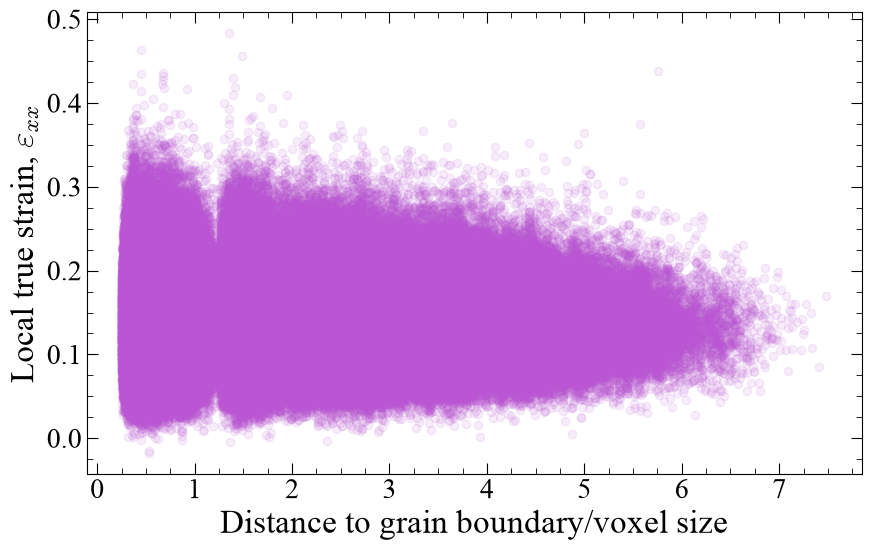

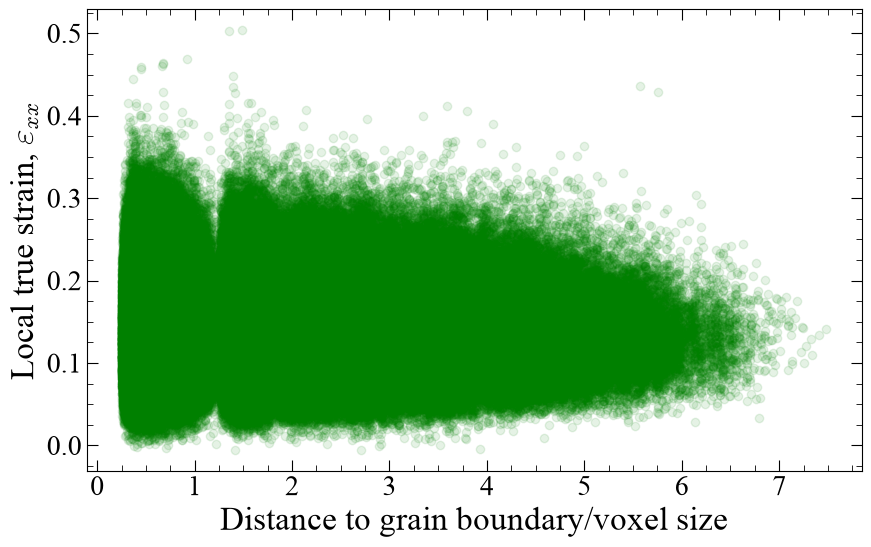

In [ ]:
plot_GB_distance_against_local_normal_strain(GB_distances, pheno_xx_strain.flatten(order = 'F'), normalisation = grid_128_VE.spacing[0], norm_label = 'voxel size', color = 'mediumorchid')
plot_GB_distance_against_local_normal_strain(GB_distances, dislo_xx_strain.flatten(order = 'F'), normalisation = grid_128_VE.spacing[0], norm_label = 'voxel size', color = 'g')

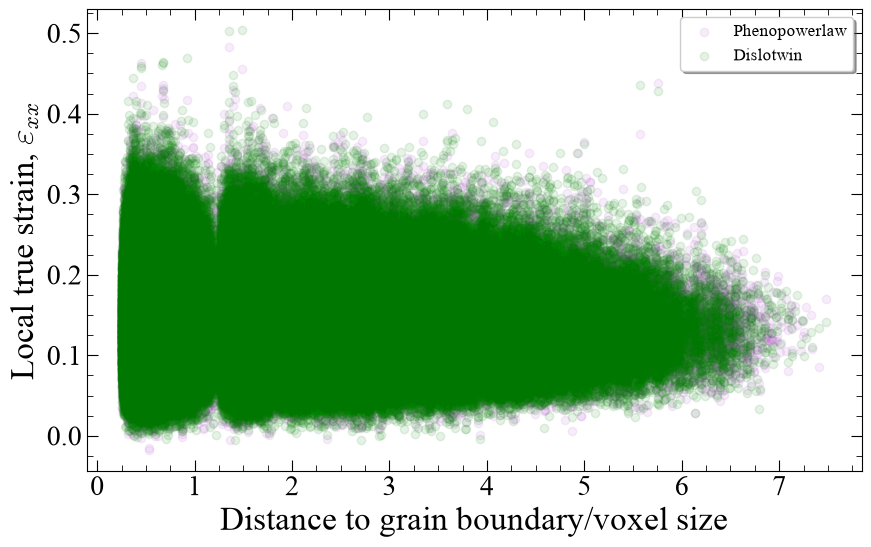

In [26]:
plot_GB_distance_against_local_normal_strain_overlap(GB_distances, local_strain_1=pheno_xx_strain.flatten(order = 'F'), local_strain_2=dislo_xx_strain.flatten(order = 'F'), normalisation=grid_128_VE.spacing[0], norm_label='voxel size', color_1='mediumorchid', color_2='g', label_1='Phenopowerlaw', label_2='Dislotwin')

No notable difference in trend - both follow bulk trend of where voxels are related to grain boundaries.

# Distance from triple points

Need function analogous to smoothing filter that creates a 3x3x3 region of the VE and counts the number of unique material IDs. If there are 3 IDs, then a triple point has been found. 

In [27]:
material_IDs = np.load('polycrystal_128_VE_material_IDs.npy')

In [121]:
test_list = [1,1,1,1,1,2,2,2,2,2,2,2,2,2,3,3,3,3,3,3,3,3,3]
[list(test_list).count(n) for n in set(test_list)]

[5, 9, 9]

In [129]:
all([[list(test_list).count(n) for n in set(test_list)][i] > 5 for i in range(3)])

False

In [28]:
triple_point_locations = []

for i in range(material_IDs.shape[0]-1):
    for j in range(material_IDs.shape[1]-1):
        for k in range(material_IDs.shape[2]-1):
            region = [material_IDs[i+1][j+1][k], material_IDs[i+1][j+1][k+1], material_IDs[i+1][j+1][k-1],
                      material_IDs[i+1][j][k], material_IDs[i+1][j][k+1], material_IDs[i+1][j][k-1],
                      material_IDs[i+1][j-1][k], material_IDs[i+1][j-1][k+1], material_IDs[i+1][j-1][k-1], 

                      material_IDs[i][j+1][k], material_IDs[i][j+1][k+1], material_IDs[i][j+1][k-1],
                      material_IDs[i][j][k], material_IDs[i][j][k+1], material_IDs[i][j][k-1],
                      material_IDs[i][j-1][k], material_IDs[i][j-1][k+1], material_IDs[i][j-1][k-1],

                      material_IDs[i-1][j+1][k], material_IDs[i-1][j+1][k+1], material_IDs[i-1][j+1][k-1],
                      material_IDs[i-1][j][k], material_IDs[i-1][j][k+1], material_IDs[i-1][j][k-1],
                      material_IDs[i-1][j-1][k], material_IDs[i-1][j-1][k+1], material_IDs[i-1][j-1][k-1], 
                      ]
            if len(np.unique(region)) == 3 and all([list(region).count(n) for n in set(region)][i] > 6 for i in range(3)):#(np.unique(region)[i] > 5 for i in range(3)):
                triple_point_locations.append([i,j,k])

In [133]:
len(triple_point_locations)/128**3

0.006826877593994141

In [29]:
triple_point_locations = np.array(triple_point_locations)

In [30]:
triple_point_coords = np.empty(triple_point_locations.shape)
for i in range(len(triple_point_locations)):
    triple_point_coords[i] = [(triple_point_locations[i][0] + 0.5)*grid_128_VE.spacing[0], 
                              (triple_point_locations[i][1] + 0.5)*grid_128_VE.spacing[0], 
                              (triple_point_locations[i][2] + 0.5)*grid_128_VE.spacing[0]]

In [31]:
triple_point_coords

array([[3.9062500e-06, 1.1718750e-05, 1.0546875e-04],
       [3.9062500e-06, 1.1718750e-05, 6.7578125e-04],
       [3.9062500e-06, 1.1718750e-05, 7.6171875e-04],
       ...,
       [9.8828125e-04, 9.1796875e-04, 9.6484375e-04],
       [9.8828125e-04, 9.4921875e-04, 1.1328125e-04],
       [9.8828125e-04, 9.8046875e-04, 1.0546875e-04]], shape=(14317, 3))

In [32]:
TP_distances = calc_voxel_distance_from_GB(triple_point_coords, voxel_128_coords)

In [149]:
TP_distances.shape

(2097152,)

Histogram of voxel distance from TP

(array([1.43170e+04, 0.00000e+00, 0.00000e+00, 0.00000e+00, 0.00000e+00,
        7.74460e+04, 0.00000e+00, 1.29672e+05, 7.46400e+04, 0.00000e+00,
        5.65540e+04, 1.88590e+05, 1.45402e+05, 0.00000e+00, 7.09870e+04,
        2.53092e+05, 8.32370e+04, 2.80940e+04, 2.04507e+05, 0.00000e+00,
        1.25496e+05, 1.03833e+05, 3.57580e+04, 8.90400e+04, 2.89340e+04,
        9.69780e+04, 2.18330e+04, 6.96510e+04, 3.12770e+04, 3.69980e+04,
        3.52500e+04, 5.72300e+03, 3.13140e+04, 1.27620e+04, 5.67200e+03,
        1.60410e+04, 9.13900e+03, 3.50000e+03, 2.48600e+03, 3.39200e+03,
        2.45600e+03, 1.11800e+03, 6.46000e+02, 5.98000e+02, 2.96000e+02,
        2.26000e+02, 9.80000e+01, 7.80000e+01, 1.00000e+01, 1.10000e+01]),
 array([0.        , 0.19899749, 0.39799497, 0.59699246, 0.79598995,
        0.99498744, 1.19398492, 1.39298241, 1.5919799 , 1.79097739,
        1.98997487, 2.18897236, 2.38796985, 2.58696734, 2.78596482,
        2.98496231, 3.1839598 , 3.38295729, 3.58195477, 3.780952

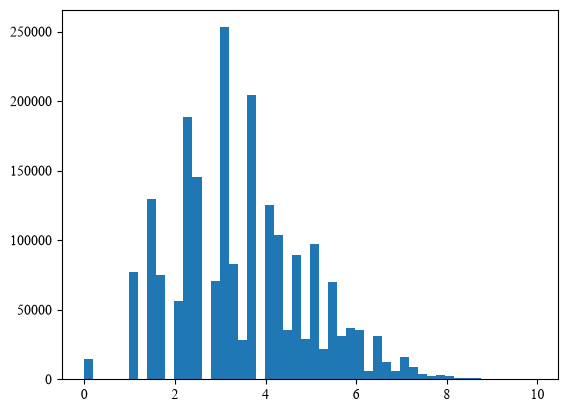

In [33]:
plt.hist(TP_distances/grid_128_VE.spacing[0], bins = 50)

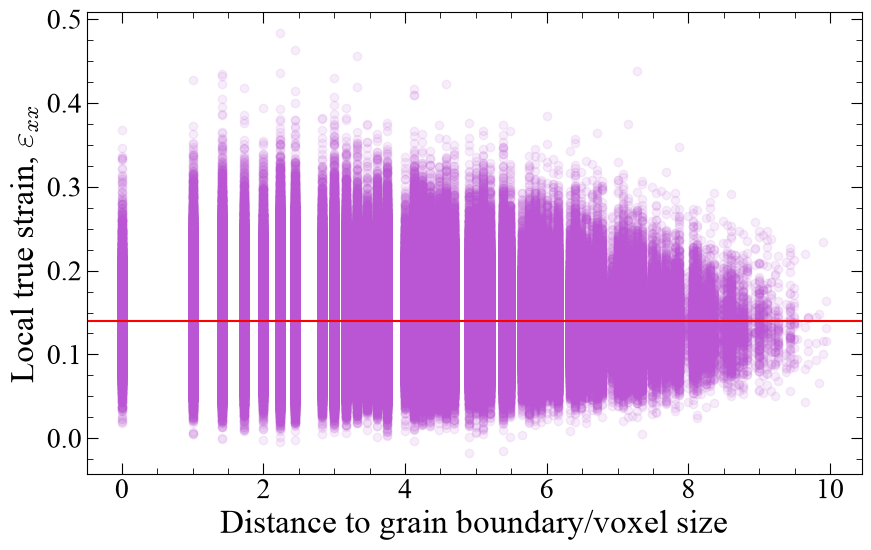

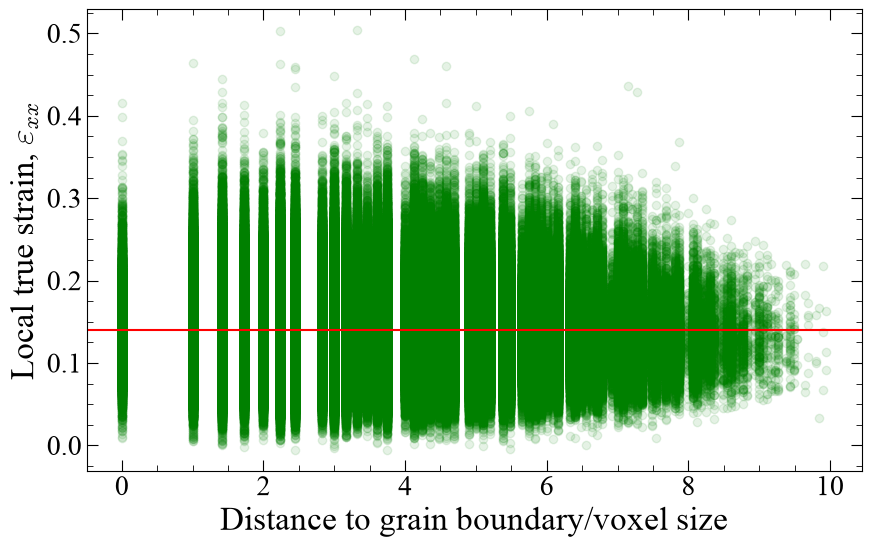

In [36]:
plot_GB_distance_against_local_normal_strain(TP_distances, pheno_xx_strain.flatten(order = 'F'), normalisation = grid_128_VE.spacing[0], norm_label = 'voxel size', color = 'mediumorchid')
#plt.ylim(np.mean(pheno_xx_strain.flatten(order = 'F')))
plt.axhline(np.mean(pheno_xx_strain.flatten(order = 'F')), color = 'r')
plot_GB_distance_against_local_normal_strain(TP_distances, dislo_xx_strain.flatten(order = 'F'), normalisation = grid_128_VE.spacing[0], norm_label = 'voxel size', color = 'g')
#plt.ylim(np.mean(dislo_xx_strain.flatten(order = 'F')))
plt.axhline(np.mean(pheno_xx_strain.flatten(order = 'F')), color = 'r')

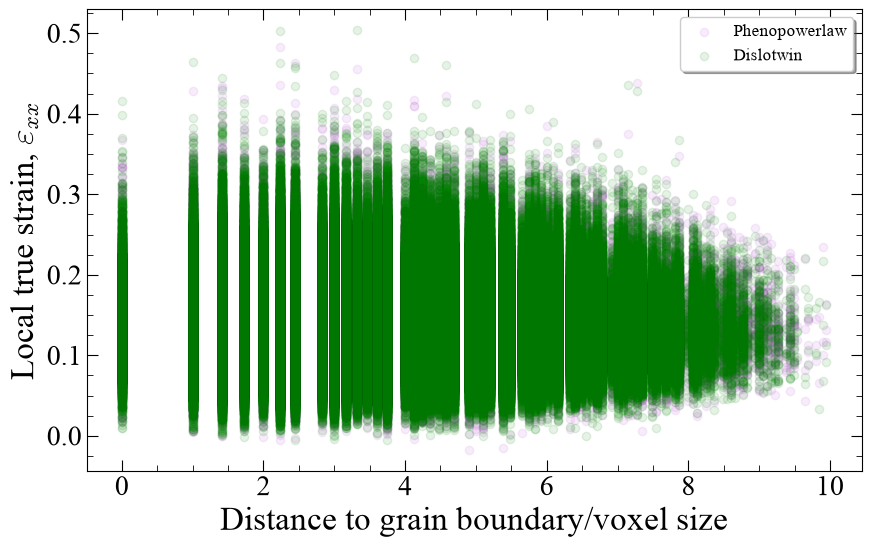

In [40]:
plot_GB_distance_against_local_normal_strain_overlap(TP_distances, local_strain_1=pheno_xx_strain.flatten(order = 'F'), local_strain_2=dislo_xx_strain.flatten(order = 'F'), normalisation=grid_128_VE.spacing[0], norm_label='voxel size', color_1='mediumorchid', color_2='g', label_1='Phenopowerlaw', label_2='Dislotwin')

Plots show the first 3 bins are: voxels at triple points, voxels neighbouring triple points by an edge, voxels neighbouring triple points by a corner.

# Statistical comparison

In [37]:
def statistical_comparison_metrics(pheno_vals, dislo_vals):
    max_val = max(max(pheno_vals.flatten(order = 'F')), max(dislo_vals.flatten(order = 'F')))
    min_val = min(min(pheno_vals.flatten(order = 'F')), min(dislo_vals.flatten(order = 'F')))

    nrmse_pheno_norm = np.sqrt(np.mean((pheno_vals - dislo_vals)**2))/np.mean(np.abs(pheno_vals))
    nrmse_dislo_norm = np.sqrt(np.mean((pheno_vals - dislo_vals)**2))/np.mean(np.abs(dislo_vals))
    ssim_score = skimage.metrics.structural_similarity(pheno_vals, dislo_vals, data_range = max_val - min_val)
    corr_coeff = np.corrcoef(pheno_vals.ravel(), dislo_vals.ravel())[0,1]
    mean_err = np.abs(np.mean(pheno_vals.flatten()) - np.mean(dislo_vals.flatten()))/(np.mean(pheno_vals.flatten()))
    print(f'NRMSE (pheno normalised): {nrmse_pheno_norm:.3f} \nNRMSE (dislo normalised): {nrmse_dislo_norm:.3f} \nSSIM: {ssim_score:.3f} \nCorrelation coefficient: {corr_coeff:.3f} \nMean error: {mean_err:.5f}')

Raw data

In [38]:
statistical_comparison_metrics(pheno_xx_strain, dislo_xx_strain)

NRMSE (pheno normalised): 0.157 
NRMSE (dislo normalised): 0.156 
SSIM: 0.782 
Correlation coefficient: 0.849 
Mean error: 0.00177


Comparison of kernel averaged images

In [39]:
#3D convolution
pheno_xx_strain_3x3x3_avg = scipy.ndimage.convolve(pheno_xx_strain, weights = [[[1/27,1/27,1/27], [1/27,1/27,1/27], [1/27,1/27,1/27]],
                                                                          [[1/27,1/27,1/27], [1/27,1/27,1/27], [1/27,1/27,1/27]],
                                                                          [[1/27,1/27,1/27], [1/27,1/27,1/27], [1/27,1/27,1/27]]])
dislo_xx_strain_3x3x3_avg = scipy.ndimage.convolve(dislo_xx_strain, weights = [[[1/27,1/27,1/27], [1/27,1/27,1/27], [1/27,1/27,1/27]],
                                                                          [[1/27,1/27,1/27], [1/27,1/27,1/27], [1/27,1/27,1/27]],
                                                                          [[1/27,1/27,1/27], [1/27,1/27,1/27], [1/27,1/27,1/27]]])

In [41]:
pheno_surface_xx_strain_3x3x3 = pheno_xx_strain_3x3x3_avg[:,:,0].transpose()
pheno_surface_xx_strain_3x3x3_flip = np.flip(pheno_surface_xx_strain_3x3x3, axis=0)

dislo_surface_xx_strain_3x3x3 = dislo_xx_strain_3x3x3_avg[:,:,0].transpose()
dislo_surface_xx_strain_3x3x3_flip = np.flip(dislo_surface_xx_strain_3x3x3, axis=0)

[]

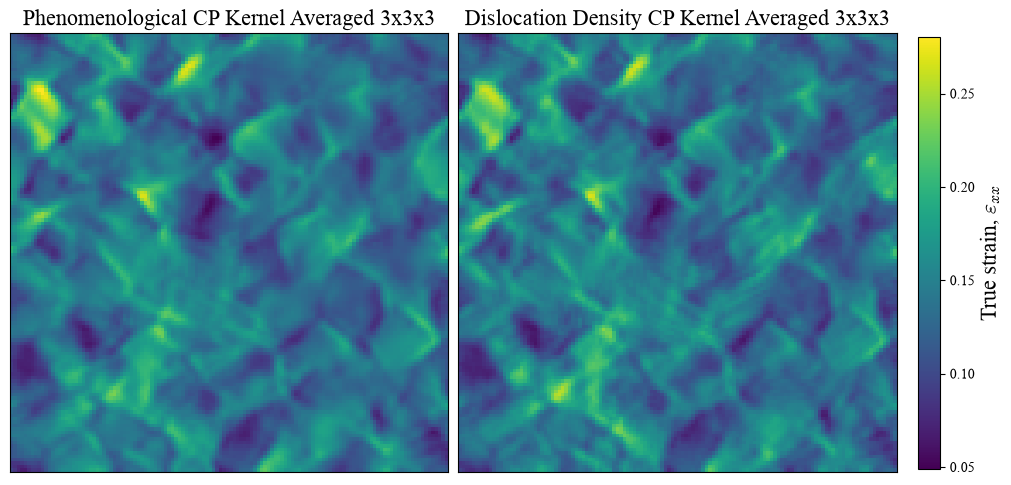

In [42]:
fig_xx_strain, ax_xx_strain = plt.subplots(1,2, figsize = (10,6), sharey=True, sharex=True, constrained_layout=True)

pheno_xx_strain_im = ax_xx_strain[0].imshow(pheno_surface_xx_strain_3x3x3_flip, vmin = min(min(value) for value in (pheno_surface_xx_strain_3x3x3_flip.flatten(), dislo_surface_xx_strain_3x3x3_flip.flatten())), vmax = max(max(value) for value in (pheno_surface_xx_strain_3x3x3_flip.flatten(), dislo_surface_xx_strain_3x3x3_flip.flatten())))
dislo_xx_strain_im = ax_xx_strain[1].imshow(dislo_surface_xx_strain_3x3x3_flip, vmin = min(min(value) for value in (pheno_surface_xx_strain_3x3x3_flip.flatten(), dislo_surface_xx_strain_3x3x3_flip.flatten())), vmax = max(max(value) for value in (pheno_surface_xx_strain_3x3x3_flip.flatten(), dislo_surface_xx_strain_3x3x3_flip.flatten())))
cbar_xx_strain = fig_xx_strain.colorbar(dislo_xx_strain_im, orientation = 'vertical', shrink=0.73)
#cbar1.set_label('True strain, $\epsilon_{xx}$', rotation = 90, fontsize = 16)
cbar_xx_strain.set_label(r'True strain, $\varepsilon_{xx}$', rotation = 90, fontsize = 16, math_fontfamily = 'cm')
#ax_load_triax[0].annotate(text = 'Layer 0, XY', xy = [1,7], color = 'w', fontsize = 20)
ax_xx_strain[0].set_title('Phenomenological CP Kernel Averaged 3x3x3', fontsize = 16)
ax_xx_strain[1].set_title('Dislocation Density CP Kernel Averaged 3x3x3', fontsize = 16)
ax_xx_strain[0].set_xticks([])
ax_xx_strain[1].set_xticks([])
ax_xx_strain[0].set_yticks([])
ax_xx_strain[1].set_yticks([])

In [43]:
statistical_comparison_metrics(pheno_xx_strain_3x3x3_avg, dislo_xx_strain_3x3x3_avg)

NRMSE (pheno normalised): 0.058 
NRMSE (dislo normalised): 0.058 
SSIM: 0.935 
Correlation coefficient: 0.963 
Mean error: 0.00177
